In [ ]:
# All paths in this notebook are relative to the repository root; anchor the working directory there
import os
while not os.path.exists('METHODOLOGY.md') and os.getcwd() != '/': os.chdir('..')
assert os.path.exists('METHODOLOGY.md'), 'run from inside the Nofit_LRT_Extension repository'

# Two-Mode Matrix from the THS 2017 Trips File — Car and Transit, with the Transit Part Calibrated to RavKav × OnBoard

A second base-year matrix built **entirely from the survey trips file** (`Input/THS_2017-2018/trips_ths_2017.xlsx`, survey days 1 and 2) — no cellular data anywhere in the chain — split into **car** and **transit**, with the bus part of transit calibrated against the two ticketing / on-board sources already processed in this repository.

## Modes

The file's `mainmode` codes, read through its own pre-aggregated `mode` groups and the 2018 codebook order (Public Bus, Matronit, Special Taxi, Group Taxi form the TRANSIT group):

| Component | `mainmode` | Treatment |
|---|---|---|
| **CAR** | 10 driver, 11 passenger | survey only (no external car data yet — screenline counts are task B1) |
| **BUS** | 3 Public Bus, 4 Matronit | **calibrated** — both are RavKav-ticketed services |
| TAXI-type | 5, 8 (Special / Group Taxi) | survey only (not in RavKav) |
| RAIL | 7 | survey only (the 2019 train matrix is a separate product) |
| OTHER | 1, 2, 9, 12, 13, 99 (walk, bicycle, …) | excluded from the two-mode matrix, reported for completeness |

**Transit = calibrated BUS + TAXI-type + RAIL** in this notebook's `transit_*` files (the two-mode split). Downstream (`THS_2017_three_mode_2022.ipynb` onwards) the taxi-type layer is kept **separate** from bus: the two codes' exact meaning is unconfirmed until the codebook is checked, and hired or shared taxis need not share bus fares, access or transfer behaviour (methodology review, §9).

## Zone conversion without cellular

`actTaz` (2636 system) → `TAZ_1250` (key file) → study TAZ. The last link is one-to-many; instead of the pipeline's cellular outflow / inflow shares, each 1250-zone's trips are split among its child TAZs by **2020 population** on the origin side and **2020 employment** on the destination side (`Input/Zonal_2020.csv`; fallback to the other variable, then uniform, where both are zero). Superzones (`SZ_NEW`, 36) and the 28 named sub-areas follow from the TAZ matrices.

## Calibration design for the bus part

RavKav (May 2022 Tuesdays, journeys counted once, both ends in the study area) measures **how many** people board where, near-census; the OnBoard survey measures **where they get off** (passenger-reported); the household survey measures the door-to-door, resident-frame pattern but on ~820 sampled bus trips per day. The calibration lets each source do what it is good at, at the scale where it is reliable — the same empirical-Bayes logic as the cellular hybrid:

1. **Destination pattern at superzone level** — $P^*(B\mid A) = \lambda_A P^{survey}(B\mid A) + (1-\lambda_A) P^{prior}(B\mid A)$, prior = RavKav × OnBoard matrix (`Output/bus/bus_od_taz_new.csv`) aggregated to superzones, $\lambda_A = n_A / (n_A + k)$ with $n_A$ the sampled survey bus trips from $A$ and $k$ chosen by **household-split validation**: the sampled households are split at random into two halves, the blend built on one half must predict the other half's rows (40 random splits, both directions). Cross-day validation — the selector used for the cellular hybrid — is reported alongside but is not used here: the two survey days are the same households repeating largely the same commutes, so day 2 is not an independent test of day 1 and that criterion always favours the raw survey.
2. **Volumes** — RavKav journey volumes where ticketing is a credible census of bus travel, survey volumes where it is not, decided **per origin superzone × destination segment** (*local* = same superzone; *inter-superzone, corridor-bound* = destination in an LRT-corridor superzone; *inter-superzone, other*). A segment with at least 5 sampled survey trips is judged on its own RavKav / survey ratio: below 0.5 the survey volume is kept (**coverage guard**), otherwise the segment is set to the RavKav volume; thinner segments inherit the origin-wide decision. Within a segment the blended pattern $P^*$ distributes the volume. The first version of this notebook applied one ratio per whole origin row; it is kept as the `binary_guard` sensitivity, together with the all-RavKav and uniform-factor variants and a threshold sweep (0.3–0.7).
3. **TAZ detail** — within each origin superzone the origin split blends the survey's home-based departure shares with RavKav boarding shares (weight $\lambda_A$); within each destination superzone the destination split blends the survey's arrival shares with OnBoard alighting shares (weight $\mu_B = m_B/(m_B+k)$, $m_B$ = sampled survey arrivals in $B$).

Vintage: the calibrated bus layer carries the 2022 RavKav level; car, taxi-type and rail stay at the 2018 survey level (`Vintage_alignment_2022.ipynb` shows how to level them).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA, PURPLE, RED = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6', '#e34948'
INK, INK2, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6); ax.set_axisbelow(True)
    for s in ax.spines.values(): s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=12)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)
OUT = 'Output/ths2017/two_mode'
os.makedirs(OUT, exist_ok=True); os.makedirs('Output/figures', exist_ok=True)
def save_show(fig, name):
    fig.savefig(f'Output/figures/{name}', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

## 1. Survey trips by mode component

In [2]:
df = pd.read_excel('Input/THS_2017-2018/trips_ths_2017.xlsx')
assert set(df['SurveyDay'].unique()) == {1, 2}
d = df.sort_values(['PerID3', 'SurveyDay', 'placeno']).copy()
g = d.groupby(['PerID3', 'SurveyDay'])
d['origin'] = g['actTaz'].shift(1); d['trip_dep_h'] = g['Dep_h'].shift(1)
trips = d.dropna(subset=['origin', 'actTaz', 'trip_dep_h'])
trips = trips[trips['trip_dep_h'].isin([6, 7, 8])].copy()

COMP = {'CAR': [10, 11], 'BUS': [3, 4], 'TAXI': [5, 8], 'RAIL': [7]}
def comp_of(m):
    for k, v in COMP.items():
        if m in v: return k
    return 'OTHER'
trips['comp'] = trips['mainmode'].map(comp_of)
chk = pd.crosstab(trips['comp'], trips['mode'])
assert chk.loc['CAR'].drop('CAR').sum() == 0 and chk.loc[['BUS', 'TAXI']].drop(columns='TRANSIT').values.sum() == 0 and chk.loc['RAIL'].drop('RAIL').sum() == 0, "component codes must nest in the file's mode groups"

k26 = pd.read_excel('Input/TAZ_2636_Keys.xlsx').drop_duplicates('TAZ_2636')
map_2636_1250 = k26.set_index('TAZ_2636')['TAZ_1250']
trips['o1250'] = trips['origin'].map(map_2636_1250); trips['d1250'] = trips['actTaz'].map(map_2636_1250)

KEYS_LFS = 'Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv'
if open(KEYS_LFS, 'rb').read(40).startswith(b'version https://git-lfs'):     # LFS pointer only: use the committed shapefile-derived copy
    keys_raw = pd.read_csv('Input/taz_keys_from_shapefile.csv')             # same 778 TAZs, SZ_NEW and TAZ_1270 (verified identical, see METHODOLOGY §1)
else:
    keys_raw = pd.read_csv(KEYS_LFS, encoding='windows-1255')
kn = keys_raw[['TAZ_1270', 'TAZ_NUMBER', 'SZ_NEW']].dropna(subset=['TAZ_NUMBER']).astype({'TAZ_NUMBER': int, 'SZ_NEW': int})
kd = kn.drop_duplicates('TAZ_NUMBER')
TAZ = np.array(sorted(kd['TAZ_NUMBER'])); N = len(TAZ); taz_pos = {t: i for i, t in enumerate(TAZ)}
sz_of = kd.set_index('TAZ_NUMBER')['SZ_NEW'].reindex(TAZ).values; SZ = sorted(set(sz_of)); sz_pos = {z: i for i, z in enumerate(SZ)}
children = kd.groupby('TAZ_1270')['TAZ_NUMBER'].apply(list)
north_1250 = sorted(children.index); z_idx = {z: i for i, z in enumerate(north_1250)}
in_study = trips['o1250'].isin(z_idx) & trips['d1250'].isin(z_idx)
excl = trips.loc[~in_study, 'new_wf'].sum() / 2
tm = trips[in_study].copy(); tm['oi'] = tm['o1250'].map(z_idx); tm['di'] = tm['d1250'].map(z_idx)
print(f"AM-peak trips (Dep_h 6–8): {len(trips):,} sampled; {(~in_study).sum():,} with an end outside the study area excluded ({excl:,.0f} avg-weekday weighted)")
summ = (tm.groupby(['comp', 'SurveyDay']).agg(sampled=('new_wf', 'size'), expanded=('new_wf', 'sum')).unstack('SurveyDay'))
summ['avg expanded'] = (summ[('expanded', 1)] + summ[('expanded', 2)]) / 2
summ['share of two-mode base'] = summ['avg expanded'] / summ.loc[['CAR', 'BUS', 'TAXI', 'RAIL'], 'avg expanded'].sum()
summ.loc['OTHER', 'share of two-mode base'] = np.nan
summ.round(3)

AM-peak trips (Dep_h 6–8): 28,060 sampled; 1,197 with an end outside the study area excluded (116,473 avg-weekday weighted)


sampled           expanded              avg expanded  \
SurveyDay       1     2            1            2                
comp                                                             
BUS           819   817   117804.480   114361.058   116082.769   
CAR          8038  7911  1297797.739  1269381.032  1283589.385   
OTHER        4467  4504   637938.395   652284.436   645111.416   
RAIL           21    33     4361.243     5856.938     5109.090   
TAXI          131   122    19400.140    17131.465    18265.802   

          share of two-mode base  
SurveyDay                         
comp                              
BUS                        0.082  
CAR                        0.902  
OTHER                        NaN  
RAIL                       0.004  
TAXI                       0.013

### 1b. Population / employment allocation to study TAZs (cellular-free)

In [3]:
zon = pd.read_csv('Input/Zonal_2020.csv', encoding='windows-1255').set_index('TAZ_ID').reindex(TAZ)
pop, emp = zon['POPULATION'].fillna(0).values, zon['EMPL_TOT'].fillna(0).values
def alloc(primary, secondary):
    S = np.zeros((len(north_1250), N)); fb = {'primary': 0, 'secondary': 0, 'uniform': 0}
    for z, kids in children.items():
        idx = [taz_pos[t] for t in kids]
        for name, v in [('primary', primary[idx]), ('secondary', secondary[idx]), ('uniform', np.ones(len(idx)))]:
            if v.sum() > 0:
                S[z_idx[z], idx] = v / v.sum(); fb[name] += 1; break
    return S, fb
S_o, fb_o = alloc(pop, emp); S_d, fb_d = alloc(emp, pop)
assert np.allclose(S_o.sum(axis=1), 1) and np.allclose(S_d.sum(axis=1), 1)
print(f"origin split (population): {fb_o} | destination split (employment): {fb_d}  — of {len(north_1250)} zones")

def m1250(sub):
    M = np.zeros((len(north_1250),) * 2); np.add.at(M, (sub['oi'].values, sub['di'].values), sub['new_wf'].values); return M
MAT = {}   # (comp, day) -> TAZ matrix
for comp in ['CAR', 'BUS', 'TAXI', 'RAIL', 'OTHER']:
    for day in (1, 2):
        MAT[(comp, day)] = S_o.T @ m1250(tm[(tm['comp'] == comp) & (tm['SurveyDay'] == day)]) @ S_d
    MAT[(comp, 'avg')] = (MAT[(comp, 1)] + MAT[(comp, 2)]) / 2
M_sz = np.zeros((N, len(SZ)))
for i, z in enumerate(sz_of): M_sz[i, sz_pos[z]] = 1
def to_sz(X): return M_sz.T @ X @ M_sz
sub_key = pd.read_excel('Input/Submatrix_tazs.xlsx')
area_of = sub_key.set_index('TAZ')['AggAreaCode']; AREA = sorted(area_of.unique())
area_names = sub_key.drop_duplicates('AggAreaCode').set_index('AggAreaCode')['AggAreaName']
M_area = np.zeros((N, len(AREA))); apos = {a: i for i, a in enumerate(AREA)}
for i, t in enumerate(TAZ):
    if t in area_of.index: M_area[i, apos[area_of[t]]] = 1
def to_area(X): return M_area.T @ X @ M_area
corridor = np.isin(TAZ, sub_key.loc[sub_key['IsLRT_Corridor'] == 1, 'TAZ'].values)
corr_sz = sorted({z for z, f in zip(sz_of, corridor) if f})
pd.DataFrame({c: {'avg-weekday trips (study area)': MAT[(c, 'avg')].sum()} for c in ['CAR', 'BUS', 'TAXI', 'RAIL', 'OTHER']}).T.round(0)

origin split (population): {'primary': 331, 'secondary': 47, 'uniform': 18} | destination split (employment): {'primary': 378, 'secondary': 0, 'uniform': 18}  — of 396 zones


,avg-weekday trips (study area)
CAR,1283589.0
BUS,116083.0
TAXI,18266.0
RAIL,5109.0
OTHER,645111.0


## 2. Ticketing side — RavKav volumes × OnBoard pattern

In [4]:
rk = pd.read_csv('Output/bus/bus_od_taz_new.csv', index_col=0); rk.index = rk.index.astype(int); rk.columns = rk.columns.astype(int)
rk = rk.reindex(index=TAZ, columns=TAZ).fillna(0).values          # journeys with both ends in the study TAZs
rk_sz = to_sz(rk)
O_rk_sz = rk_sz.sum(axis=1); D_rk_sz = rk_sz.sum(axis=0)
P_prior = rk_sz / np.where(O_rk_sz[:, None] > 0, O_rk_sz[:, None], 1)
assert (O_rk_sz > 0).all(), "every superzone needs RavKav boardings for the prior"
rk_o_taz, rk_d_taz = rk.sum(axis=1), rk.sum(axis=0)
# RavKav's own inferred alightings (journey-level), for a destination-side cross-check
rk_raw = pd.read_csv('Output/bus/bus_od_taz_avg.csv', index_col=0); rk_raw.index = rk_raw.index.astype(int); rk_raw.columns = rk_raw.columns.astype(int)
D_rk_raw_sz = M_sz.T @ rk_raw.reindex(index=TAZ, columns=TAZ).fillna(0).values.sum(axis=0)
print(f"RavKav × OnBoard bus journeys with both ends in the 778 study TAZs: {rk.sum():,.0f} (avg Tuesday, 6–9)")
print(f"survey BUS (Public Bus + Matronit), avg weekday, study area: {MAT[('BUS', 'avg')].sum():,.0f}  → overall ratio RavKav / survey = {rk.sum() / MAT[('BUS', 'avg')].sum():.3f}")

RavKav × OnBoard bus journeys with both ends in the 778 study TAZs: 92,713 (avg Tuesday, 6–9)
survey BUS (Public Bus + Matronit), avg weekday, study area: 116,083  → overall ratio RavKav / survey = 0.799


## 3. Calibration step 1 — destination pattern at superzone level (empirical Bayes, $k$ by cross-day validation)

In [5]:
def rownorm(X):
    rs = X.sum(axis=1, keepdims=True); return np.where(rs > 0, X / np.where(rs == 0, 1, rs), 0)
def jsd(p, q):
    if p.sum() <= 0 or q.sum() <= 0: return np.nan
    p, q = p / p.sum(), q / q.sum(); m = (p + q) / 2
    kl = lambda a, b: np.sum(a[a > 0] * np.log2(a[a > 0] / b[a > 0]))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

# sampled bus trips per origin superzone per day (dominant superzone of the trip's origin 1250-zone)
dom_sz = {z: pd.Series(pop[[taz_pos[t] for t in kids]] + 1e-9, index=[sz_of[taz_pos[t]] for t in kids]).groupby(level=0).sum().idxmax() for z, kids in children.items()}   # dominant superzone by 2020 population of the child TAZs
bus = tm[tm['comp'] == 'BUS']
n_day = {day: bus[bus['SurveyDay'] == day].groupby(bus['o1250'].map(dom_sz)).size().reindex(SZ).fillna(0).values for day in (1, 2)}
n_pool = n_day[1] + n_day[2]
P1, P2 = rownorm(to_sz(MAT[('BUS', 1)])), rownorm(to_sz(MAT[('BUS', 2)]))
P_avg = rownorm(to_sz(MAT[('BUS', 'avg')]))

K_GRID = [0, 1, 2, 5, 10, 20, 50, 100, 200, 500, np.inf]
def blend(P, n, k):
    lam = np.zeros(len(n)) if not np.isfinite(k) else np.divide(n, n + k, out=np.zeros(len(n)), where=(n + k) > 0)
    return P * lam[:, None] + P_prior * (1 - lam[:, None]), lam
def row_jsd(Pa, Pb):
    return np.nanmean([jsd(Pa[i], Pb[i]) for i in range(len(SZ))])

# (a) cross-day validation — reference only (same households on both days)
cv_day = pd.Series({k: (row_jsd(blend(P1, n_day[1], k)[0], P2) + row_jsd(blend(P2, n_day[2], k)[0], P1)) / 2 for k in K_GRID}, name='cross-day')

# (b) household-split validation — independent halves of the sample, both days pooled
rng = np.random.default_rng(42)
hh = bus['HHID3'].values; hh_ids = np.unique(hh)
o_dom = bus['o1250'].map(dom_sz).values
def half_rows(mask):
    sub = bus[mask]
    P = rownorm(to_sz(S_o.T @ m1250(sub) @ S_d))
    n = pd.Series(o_dom[mask]).value_counts().reindex(SZ).fillna(0).values
    return P, n
acc = {k: [] for k in K_GRID}
for _ in range(40):
    pick = rng.permutation(hh_ids); A = np.isin(hh, pick[: len(pick) // 2])
    Pa, na = half_rows(A); Pb, nb = half_rows(~A)
    for k in K_GRID:
        acc[k].append((row_jsd(blend(Pa, na, k)[0], Pb) + row_jsd(blend(Pb, nb, k)[0], Pa)) / 2)
cv_hh = pd.Series({k: np.mean(v) for k, v in acc.items()}, name='household-split')
cv = pd.concat([cv_hh, cv_day], axis=1); cv.index.name = 'k'
cv.to_csv(f'{OUT}/bus_calibration_cv.csv')
k_star = cv_hh.idxmin()
print("validation of the shrinkage constant (mean row JSD on the held-out half / day; lower is better):"); print(cv.round(5).to_string())
print(f"\nk* = {k_star:g} by household split (cross-day would give {cv_day.idxmin():g})   [k = 0: pure survey rows; k = inf: pure RavKav × OnBoard rows]")
P_star, lam = blend(P_avg, n_pool, k_star)
lam_tbl = pd.DataFrame({'origin SZ': SZ, 'corridor': [z in corr_sz for z in SZ], 'n sampled (2 days)': n_pool.astype(int), 'lambda (survey weight)': lam})
print(f"lambda: min {lam.min():.2f}, median {np.median(lam):.2f}, max {lam.max():.2f}; trip-weighted mean {np.average(lam, weights=O_rk_sz):.2f}")

validation of the shrinkage constant (mean row JSD on the held-out half / day; lower is better):
       household-split  cross-day
k                                
0.0            0.35318    0.10603
1.0            0.33618    0.12591
2.0            0.33196    0.14129
5.0            0.33138    0.17370
10.0           0.33794    0.20790
20.0           0.35141    0.24804
50.0           0.37570    0.30158
100.0          0.39391    0.33560
200.0          0.40866    0.36089
500.0          0.42147    0.38155
inf            0.43336    0.39978

k* = 5 by household split (cross-day would give 0)   [k = 0: pure survey rows; k = inf: pure RavKav × OnBoard rows]
lambda: min 0.29, median 0.86, max 0.97; trip-weighted mean 0.86


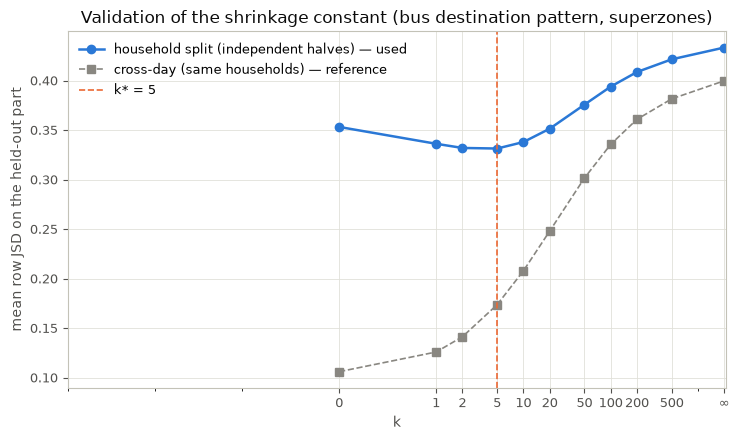

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5), facecolor='white')
xs = [k if np.isfinite(k) else 2000 for k in cv.index]
ax.plot(xs, cv['household-split'].values, marker='o', color=BLUE, linewidth=1.8, label='household split (independent halves) — used')
ax.plot(xs, cv['cross-day'].values, marker='s', color=MUTED, linewidth=1.2, linestyle='--', label='cross-day (same households) — reference')
ax.axvline(k_star if np.isfinite(k_star) else 2000, color=ORANGE, linestyle='--', linewidth=1.2, label=f'k* = {k_star:g}')
ax.set_xscale('symlog', linthresh=1); ax.set_xticks(xs); ax.set_xticklabels([f'{k:g}' if np.isfinite(k) else '∞' for k in cv.index])
style_ax(ax, 'Validation of the shrinkage constant (bus destination pattern, superzones)', 'k', 'mean row JSD on the held-out part')
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); save_show(fig, 'two_mode_bus_cv.png')

## 4. Calibration step 2 — origin volumes from RavKav boardings, with a segmented coverage rule

The first version of this notebook applied one coverage test per origin superzone (RavKav / survey ratio over *all* its bus trips; below 0.5 → survey volume kept). `Corridor_profile_hybrid_vs_ticketing.ipynb` then showed that the shortfall is a **local-trip** problem (Nazareth: ticketing sees 8 % of the survey's intra-superzone bus trips but 74 % of its trips to the Haifa superzones), and the methodology review (§8) asked for the rule to be segmented by movement type. The rule is now applied **per origin superzone × destination segment** — *local* (destination in the same superzone), *inter-superzone corridor-bound* (destination in an LRT-corridor superzone) and *inter-superzone other* — each segment with ≥ 5 sampled survey trips judged on its own ratio, thinner segments inheriting the origin-wide decision. The origin-wide binary rule is kept as a saved sensitivity (`bus_calibrated_binary_guard_*`).

In [7]:
O_sv_sz = to_sz(MAT[('BUS', 'avg')]).sum(axis=1)
f_sz = O_rk_sz / O_sv_sz
f_uniform = O_rk_sz.sum() / O_sv_sz.sum()
leg = pd.read_csv('Output/bus/bus_boardings_alightings_taz.csv').set_index('TAZ_NUMBER').reindex(TAZ).fillna(0)
leg_b_sz = M_sz.T @ leg['avg_boardings'].values
COVERAGE_MIN = 0.5
sz_loc = pd.read_csv('Input/sz_localities.csv').set_index('SZ_NEW')['main localities']   # two largest localities per superzone by population (from the keys table's CITY field)
arab = (zon['SECTOR_ARA'].fillna(0) * pop).values
def cities(z): return sz_loc.get(z, '')
fac = pd.DataFrame({'origin SZ': SZ, 'corridor': [z in corr_sz for z in SZ], 'main localities': [cities(z) for z in SZ],
                    'Arab-sector pop share': [arab[sz_of == z].sum() / max(pop[sz_of == z].sum(), 1) for z in SZ],
                    'survey BUS departures': O_sv_sz, 'RavKav journey boardings': O_rk_sz, 'ratio RavKav / survey': f_sz,
                    'RavKav leg boardings / journeys': leg_b_sz / O_rk_sz, 'n sampled (2 days)': n_pool.astype(int), 'lambda': lam})
guard = f_sz < COVERAGE_MIN                       # origin-wide binary rule (first version) — kept as the sensitivity variant
fac['factor applied'] = np.where(guard, 1.0, f_sz)
fac['flag'] = np.where(guard, 'ticketing under-coverage → survey volume kept',
               np.where(fac['RavKav leg boardings / journeys'] > 2.5, 'transfer hub (boarding frame)', np.where(f_sz > 2, 'thin survey row, RavKav volume', '')))
fac.to_csv(f'{OUT}/bus_calibration_factors_sz.csv', index=False, float_format='%.4f')
f_applied = fac['factor applied'].values
print(f"regional ratio RavKav / survey: {f_uniform:.3f}; per-superzone ratios: median {np.median(f_sz):.2f}, range {f_sz.min():.2f}–{f_sz.max():.2f}")
print(f"coverage guard (ratio < {COVERAGE_MIN}): {guard.sum()} superzones keep the survey volume — "
      f"{fac.loc[guard, 'survey BUS departures'].sum():,.0f} survey bus trips vs {fac.loc[guard, 'RavKav journey boardings'].sum():,.0f} ticketed; "
      f"Arab-sector population share in them {np.average(fac.loc[guard, 'Arab-sector pop share'], weights=fac.loc[guard, 'survey BUS departures']):.0%} vs {np.average(fac.loc[~guard, 'Arab-sector pop share'], weights=fac.loc[~guard, 'survey BUS departures']):.0%} elsewhere")
print(fac.drop(columns=['lambda']).sort_values('ratio RavKav / survey').round(2).to_string(index=False))

# ---- segmented coverage rule: origin superzone × destination segment ----
S_sv, S_rk = to_sz(MAT[('BUS', 'avg')]), rk_sz
is_corr = np.array([z in corr_sz for z in SZ])
SEG = ['local', 'inter-SZ, corridor-bound', 'inter-SZ, other']
seg_of = np.where(np.eye(len(SZ), dtype=bool), 0, np.where(is_corr[None, :], 1, 2))          # segment index of block (A, B)
bus_o, bus_d = bus['o1250'].map(dom_sz).values, bus['d1250'].map(dom_sz).values
seg_trip = np.where(bus_o == bus_d, 0, np.where(np.isin(bus_d, np.array(SZ)[is_corr]), 1, 2))
n_seg = np.zeros((len(SZ), 3)); np.add.at(n_seg, ([sz_pos[z] for z in bus_o], seg_trip), 1)
N_MIN_SEG = 5
def segment_factors(cmin):
    guard_o = f_sz < cmin
    f_seg, guard_seg, rows = np.ones((len(SZ), 3)), np.zeros((len(SZ), 3), bool), []
    for a, A in enumerate(SZ):
        for s in range(3):
            m = seg_of[a] == s
            sv, rkv = S_sv[a, m].sum(), S_rk[a, m].sum()
            if sv <= 0:
                f, gd, basis = 1.0, False, 'no survey trips in segment'
            elif n_seg[a, s] >= N_MIN_SEG:
                gd = rkv / sv < cmin; f = 1.0 if gd else rkv / sv; basis = 'segment ratio'
            else:
                gd = bool(guard_o[a]); f = 1.0 if gd else f_sz[a]; basis = f'origin-wide ratio (segment has < {N_MIN_SEG} sampled trips)'
            f_seg[a, s], guard_seg[a, s] = f, gd
            rows.append({'origin SZ': A, 'corridor': is_corr[a], 'segment': SEG[s], 'survey BUS trips': sv, 'RavKav journeys': rkv,
                         'ratio RavKav / survey': rkv / sv if sv > 0 else np.nan, 'n sampled (2 days)': int(n_seg[a, s]), 'basis': basis,
                         'guarded': gd, 'factor applied': f, 'flag': 'ticketing under-coverage → survey volume kept' if gd else ''})
    return f_seg, guard_seg, rows
f_seg, guard_seg, rows = segment_factors(COVERAGE_MIN)
seg_tbl = pd.DataFrame(rows); seg_tbl.to_csv(f'{OUT}/bus_calibration_factors_segments.csv', index=False, float_format='%.4f')
gs = seg_tbl[seg_tbl['guarded']]
print(f"\nsegmented rule: {len(gs)} origin × segment cells keep the survey volume ({gs['survey BUS trips'].sum():,.0f} survey trips vs {gs['RavKav journeys'].sum():,.0f} ticketed) — "
      f"binary rule: {guard.sum()} whole origins ({fac.loc[guard, 'survey BUS departures'].sum():,.0f} vs {fac.loc[guard, 'RavKav journey boardings'].sum():,.0f})")
print("guarded segments:"); print(gs[['origin SZ', 'segment', 'survey BUS trips', 'RavKav journeys', 'ratio RavKav / survey', 'n sampled (2 days)', 'basis']].round(2).to_string(index=False))
print("\nsegments of the origins the binary rule guarded, and how the segmented rule treats them:")
print(seg_tbl[seg_tbl['origin SZ'].isin(fac.loc[guard, 'origin SZ'])][['origin SZ', 'segment', 'survey BUS trips', 'RavKav journeys', 'ratio RavKav / survey', 'n sampled (2 days)', 'guarded', 'factor applied', 'basis']].round(2).to_string(index=False))

regional ratio RavKav / survey: 0.799; per-superzone ratios: median 0.89, range 0.21–5.77
coverage guard (ratio < 0.5): 7 superzones keep the survey volume — 25,203 survey bus trips vs 7,261 ticketed; Arab-sector population share in them 76% vs 19% elsewhere
 origin SZ  corridor                         main localities  Arab-sector pop share  survey BUS departures  RavKav journey boardings  ratio RavKav / survey  RavKav leg boardings / journeys  n sampled (2 days)  factor applied                                          flag
        19      True                           נצרת, כפר כנא                   0.99               12429.13                   2642.75                   0.21                             1.32                  88            1.00 ticketing under-coverage → survey volume kept
        30     False                           סח'נין, עראבה                   1.00                1016.50                    289.50                   0.28                             1.10           

## 5. Calibrated bus matrix — superzone level, then TAZ detail

In [8]:
def segment_volumes(f_seg):
    # segment target = factor × survey segment volume (factor = RavKav / survey where credible, 1 where guarded); blended pattern P* within the segment
    T = np.zeros_like(P_star)
    for a in range(len(SZ)):
        for s in range(3):
            m = seg_of[a] == s; target = f_seg[a, s] * S_sv[a, m].sum(); pm = P_star[a, m].sum()
            if target > 0 and pm > 0: T[a, m] = target * P_star[a, m] / pm
            elif target > 0: T[a, m] = target * S_sv[a, m] / S_sv[a, m].sum()
    return T
T_sz = segment_volumes(f_seg)                           # primary: segmented coverage rule (local / corridor-bound / other), blended pattern within segment
T_sz_binary = (f_applied * O_sv_sz)[:, None] * P_star   # sensitivity: origin-wide binary coverage rule (first version of this notebook)
loc = np.eye(len(SZ), dtype=bool)
sens = []
for cmin in [0.3, 0.4, 0.5, 0.6, 0.7]:
    fs, gs_, _ = segment_factors(cmin); Ts = segment_volumes(fs)
    sens.append({'coverage threshold': cmin, 'guarded segments': int(gs_.sum()), 'bus total': Ts.sum(), 'local': Ts[loc].sum(), 'inter-SZ': Ts[~loc].sum(),
                 'corridor SZ origins': Ts[is_corr].sum()})
sens = pd.DataFrame(sens); sens.to_csv(f'{OUT}/bus_calibration_threshold_sensitivity.csv', index=False, float_format='%.1f')
print("sensitivity of the segmented rule to the coverage threshold (survey bus 2018: total %.0f, local %.0f, inter-SZ %.0f; RavKav: %.0f / %.0f / %.0f):"
      % (S_sv.sum(), S_sv[loc].sum(), S_sv[~loc].sum(), S_rk.sum(), S_rk[loc].sum(), S_rk[~loc].sum()))
print(sens.round({'bus total': 0, 'local': 0, 'inter-SZ': 0, 'corridor SZ origins': 0}).to_string(index=False))
T_sz_full = O_rk_sz[:, None] * P_star                   # sensitivity: RavKav volumes everywhere
T_sz_uniform = (f_uniform * O_sv_sz)[:, None] * P_star  # sensitivity: one regional factor
assert abs(T_sz_full.sum() - O_rk_sz.sum()) < 1e-6

# TAZ detail: origin split within A, destination split within B
sv_o_taz, sv_d_taz = MAT[('BUS', 'avg')].sum(axis=1), MAT[('BUS', 'avg')].sum(axis=0)
m_day = {day: bus[bus['SurveyDay'] == day].groupby(bus['d1250'].map(dom_sz)).size().reindex(SZ).fillna(0).values for day in (1, 2)}
m_pool = m_day[1] + m_day[2]
k_eff = max(float(k_star), 1e-9)
mu = np.where(m_pool > 0, m_pool / (m_pool + k_eff), 0.0)
def within_shares(v_survey, v_tick, weight):
    s = np.zeros(N)
    for zi, z in enumerate(SZ):
        m = sz_of == z
        a = v_survey[m] / v_survey[m].sum() if v_survey[m].sum() > 0 else np.zeros(m.sum())
        b = v_tick[m] / v_tick[m].sum() if v_tick[m].sum() > 0 else np.full(m.sum(), 1 / m.sum())
        s[m] = weight[zi] * a + (1 - weight[zi]) * b if v_survey[m].sum() > 0 else b
    return s
s_o = within_shares(sv_o_taz, rk_o_taz, lam)     # origin split: survey home-based shares blended with RavKav boarding shares
s_d = within_shares(sv_d_taz, rk_d_taz, mu)      # destination split: survey arrival shares blended with OnBoard alighting shares
col = np.array([sz_pos[z] for z in sz_of])
T_bus = T_sz[col][:, col] * s_o[:, None] * s_d[None, :]
assert np.allclose(to_sz(T_bus), T_sz), "TAZ matrix must aggregate back to the superzone matrix"
T_bus_uniform = T_sz_uniform[col][:, col] * s_o[:, None] * s_d[None, :]
T_bus_full = T_sz_full[col][:, col] * s_o[:, None] * s_d[None, :]
T_bus_binary = T_sz_binary[col][:, col] * s_o[:, None] * s_d[None, :]
print(f"calibrated BUS (segmented coverage rule): {T_bus.sum():,.0f} trips vs survey BUS {MAT[('BUS', 'avg')].sum():,.0f} (2018); binary-guard variant {T_bus_binary.sum():,.0f}; all-RavKav variant {T_bus_full.sum():,.0f} (2022 ticketing level)")
print(f"local (intra-superzone) bus trips: survey {S_sv[loc].sum():,.0f} → segmented {T_sz[loc].sum():,.0f} (binary {T_sz_binary[loc].sum():,.0f}, RavKav {S_rk[loc].sum():,.0f}); "
      f"inter-superzone: survey {S_sv[~loc].sum():,.0f} → segmented {T_sz[~loc].sum():,.0f} (binary {T_sz_binary[~loc].sum():,.0f}, RavKav {S_rk[~loc].sum():,.0f})")
print(f"destination-split weights mu_B: median {np.median(mu):.2f}; sampled arrivals per superzone median {np.median(m_pool):.0f}")

sensitivity of the segmented rule to the coverage threshold (survey bus 2018: total 116083, local 62090, inter-SZ 53992; RavKav: 92713 / 23277 / 69436):
 coverage threshold  guarded segments  bus total   local  inter-SZ  corridor SZ origins
                0.3                19   117515.0 54406.0   63109.0              53242.0
                0.4                24   122160.0 57042.0   65118.0              53915.0
                0.5                28   126117.0 60200.0   65917.0              54596.0
                0.6                38   130639.0 62723.0   67916.0              56787.0
                0.7                44   131650.0 63541.0   68109.0              57049.0
calibrated BUS (segmented coverage rule): 126,117 trips vs survey BUS 116,083 (2018); binary-guard variant 110,654; all-RavKav variant 92,713 (2022 ticketing level)
local (intra-superzone) bus trips: survey 62,090 → segmented 60,200 (binary 51,007, RavKav 23,277); inter-superzone: survey 53,992 → segmented 65,917 (bin

## 6. Assemble the two-mode matrix

In [9]:
TRANSIT_cal = T_bus + MAT[('TAXI', 'avg')] + MAT[('RAIL', 'avg')]
TRANSIT_sv = MAT[('BUS', 'avg')] + MAT[('TAXI', 'avg')] + MAT[('RAIL', 'avg')]
CAR = MAT[('CAR', 'avg')]
def save(X, name, labels, idx_name):
    df_ = pd.DataFrame(X, index=labels, columns=labels); df_.index.name = idx_name
    df_.to_csv(f'{OUT}/{name}.csv', float_format='%.6g')
for name, X in {'car_taz': CAR, 'transit_taz': TRANSIT_cal, 'transit_survey_taz': TRANSIT_sv, 'bus_calibrated_taz': T_bus,
                'bus_survey_taz': MAT[('BUS', 'avg')], 'taxi_survey_taz': MAT[('TAXI', 'avg')], 'rail_survey_taz': MAT[('RAIL', 'avg')],
                'bus_calibrated_uniform_factor_taz': T_bus_uniform, 'bus_calibrated_all_ravkav_taz': T_bus_full, 'bus_calibrated_binary_guard_taz': T_bus_binary}.items():
    save(X, name, TAZ, 'orig_taz')
for name, X in {'car_sz': CAR, 'transit_sz': TRANSIT_cal, 'transit_survey_sz': TRANSIT_sv, 'bus_calibrated_sz': T_bus, 'bus_survey_sz': MAT[('BUS', 'avg')], 'bus_calibrated_all_ravkav_sz': T_bus_full, 'bus_calibrated_binary_guard_sz': T_bus_binary}.items():
    save(to_sz(X), name, SZ, 'origin_sz')
for name, X in {'car_area': CAR, 'transit_area': TRANSIT_cal, 'transit_survey_area': TRANSIT_sv, 'bus_calibrated_area': T_bus}.items():
    save(to_area(X), name, AREA, 'AggAreaCode')
pd.DataFrame(P_star, index=SZ, columns=SZ).to_csv(f'{OUT}/bus_pattern_sz_prob.csv', float_format='%.6g')
lam_tbl.to_csv(f'{OUT}/bus_calibration_lambda_sz.csv', index=False, float_format='%.4f')

tot = pd.DataFrame({'survey (2018)': {'CAR': CAR.sum(), 'BUS': MAT[('BUS', 'avg')].sum(), 'TAXI-type': MAT[('TAXI', 'avg')].sum(), 'RAIL': MAT[('RAIL', 'avg')].sum(), 'TRANSIT total': TRANSIT_sv.sum()},
                    'binary guard (first version)': {'CAR': CAR.sum(), 'BUS': T_bus_binary.sum(), 'TAXI-type': MAT[('TAXI', 'avg')].sum(), 'RAIL': MAT[('RAIL', 'avg')].sum(), 'TRANSIT total': T_bus_binary.sum() + MAT[('TAXI', 'avg')].sum() + MAT[('RAIL', 'avg')].sum()},
                    'calibrated (segmented rule)': {'CAR': CAR.sum(), 'BUS': T_bus.sum(), 'TAXI-type': MAT[('TAXI', 'avg')].sum(), 'RAIL': MAT[('RAIL', 'avg')].sum(), 'TRANSIT total': TRANSIT_cal.sum()}})
tot['transit share (two-mode base)'] = np.nan
tot.loc['TRANSIT total', 'transit share (two-mode base)'] = TRANSIT_cal.sum() / (CAR.sum() + TRANSIT_cal.sum())
print(f"transit share of the two-mode base: survey {TRANSIT_sv.sum() / (CAR.sum() + TRANSIT_sv.sum()):.1%} → calibrated {TRANSIT_cal.sum() / (CAR.sum() + TRANSIT_cal.sum()):.1%}")
tot.round(0)

transit share of the two-mode base: survey 9.8% → calibrated 10.4%


,survey (2018),binary guard (first version),calibrated (segmented rule),transit share (two-mode base)
CAR,1283589.0,1283589.0,1283589.0,NaN
BUS,116083.0,110654.0,126117.0,NaN
TAXI-type,18266.0,18266.0,18266.0,NaN
RAIL,5109.0,5109.0,5109.0,NaN
TRANSIT total,139458.0,134029.0,149492.0,0.0


## 7. Validation

- **Held-out day**: the pattern calibration is judged by whether a blend built on one day predicts the other day better than the raw survey day does (the CV table above: JSD at $k^*$ vs $k = 0$).
- **Against the ticketing matrix**: calibrated bus vs RavKav × OnBoard at superzone and 28-area level (cosine of the flattened matrices, share of flow in cells within GEH 5 on hourly flows), and the same for the raw survey bus.
- **Destination side**: the calibrated column totals were never forced; compare them with OnBoard-informed alightings and RavKav's own inferred alightings per superzone.

In [10]:
def cosine(a, b):
    a, b = np.asarray(a, float).ravel(), np.asarray(b, float).ravel(); return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))
def geh_pass(m, c):
    m, c = np.asarray(m, float) / 3, np.asarray(c, float) / 3; s = m + c; ok = s > 0
    G = np.sqrt(2 * (m[ok] - c[ok]) ** 2 / s[ok]); w = s[ok] / 2
    return float(w[G < 5].sum() / w.sum())
rk_area = to_area(rk)
val = pd.DataFrame([
    {'level': 'SZ', 'pair': 'survey BUS vs RavKav×OnBoard', 'cosine': cosine(to_sz(MAT[('BUS', 'avg')]), rk_sz), 'cosine row-normalized': cosine(P_avg, P_prior), 'GEH<5 (flow-wtd)': geh_pass(to_sz(MAT[('BUS', 'avg')]), rk_sz)},
    {'level': 'SZ', 'pair': 'calibrated BUS vs RavKav×OnBoard', 'cosine': cosine(T_sz, rk_sz), 'cosine row-normalized': cosine(P_star, P_prior), 'GEH<5 (flow-wtd)': geh_pass(T_sz, rk_sz)},
    {'level': 'SZ', 'pair': 'calibrated BUS vs survey BUS', 'cosine': cosine(T_sz, to_sz(MAT[('BUS', 'avg')])), 'cosine row-normalized': cosine(P_star, P_avg), 'GEH<5 (flow-wtd)': geh_pass(T_sz, to_sz(MAT[('BUS', 'avg')]))},
    {'level': 'SZ', 'pair': 'binary-guard variant vs RavKav×OnBoard', 'cosine': cosine(T_sz_binary, rk_sz), 'cosine row-normalized': cosine(P_star, P_prior), 'GEH<5 (flow-wtd)': geh_pass(T_sz_binary, rk_sz)},
    {'level': 'SZ', 'pair': 'all-RavKav variant vs RavKav×OnBoard', 'cosine': cosine(T_sz_full, rk_sz), 'cosine row-normalized': cosine(P_star, P_prior), 'GEH<5 (flow-wtd)': geh_pass(T_sz_full, rk_sz)},
    {'level': 'SZ', 'pair': 'survey BUS day 1 vs day 2', 'cosine': cosine(to_sz(MAT[('BUS', 1)]), to_sz(MAT[('BUS', 2)])), 'cosine row-normalized': cosine(P1, P2), 'GEH<5 (flow-wtd)': geh_pass(to_sz(MAT[('BUS', 1)]), to_sz(MAT[('BUS', 2)]))},
    {'level': 'AREA', 'pair': 'survey BUS vs RavKav×OnBoard', 'cosine': cosine(to_area(MAT[('BUS', 'avg')]), rk_area), 'cosine row-normalized': cosine(rownorm(to_area(MAT[('BUS', 'avg')])), rownorm(rk_area)), 'GEH<5 (flow-wtd)': geh_pass(to_area(MAT[('BUS', 'avg')]), rk_area)},
    {'level': 'AREA', 'pair': 'calibrated BUS vs RavKav×OnBoard', 'cosine': cosine(to_area(T_bus), rk_area), 'cosine row-normalized': cosine(rownorm(to_area(T_bus)), rownorm(rk_area)), 'GEH<5 (flow-wtd)': geh_pass(to_area(T_bus), rk_area)},
    {'level': 'AREA', 'pair': 'binary-guard variant vs RavKav×OnBoard', 'cosine': cosine(to_area(T_bus_binary), rk_area), 'cosine row-normalized': cosine(rownorm(to_area(T_bus_binary)), rownorm(rk_area)), 'GEH<5 (flow-wtd)': geh_pass(to_area(T_bus_binary), rk_area)},
    {'level': 'AREA', 'pair': 'calibrated BUS vs survey BUS', 'cosine': cosine(to_area(T_bus), to_area(MAT[('BUS', 'avg')])), 'cosine row-normalized': cosine(rownorm(to_area(T_bus)), rownorm(to_area(MAT[('BUS', 'avg')]))), 'GEH<5 (flow-wtd)': geh_pass(to_area(T_bus), to_area(MAT[('BUS', 'avg')]))},
    {'level': 'AREA', 'pair': 'survey BUS day 1 vs day 2', 'cosine': cosine(to_area(MAT[('BUS', 1)]), to_area(MAT[('BUS', 2)])), 'cosine row-normalized': cosine(rownorm(to_area(MAT[('BUS', 1)])), rownorm(to_area(MAT[('BUS', 2)]))), 'GEH<5 (flow-wtd)': geh_pass(to_area(MAT[('BUS', 1)]), to_area(MAT[('BUS', 2)]))},
])
val.to_csv(f'{OUT}/bus_calibration_validation.csv', index=False, float_format='%.4f')
print(f"held-out household half: mean row JSD {cv_hh[k_star]:.4f} at k* vs {cv_hh[0]:.4f} for raw survey rows (k = 0) and {cv_hh[np.inf]:.4f} for pure RavKav×OnBoard rows")
val.round(3)

held-out household half: mean row JSD 0.3314 at k* vs 0.3532 for raw survey rows (k = 0) and 0.4334 for pure RavKav×OnBoard rows


,level,pair,cosine,cosine row-normalized,GEH<5 (flow-wtd)
0,SZ,survey BUS vs RavKav×OnBoard,0.589,0.618,0.191
1,SZ,calibrated BUS vs RavKav×OnBoard,0.601,0.731,0.367
2,SZ,calibrated BUS vs survey BUS,0.978,0.963,0.737
3,SZ,binary-guard variant vs RavKav×OnBoard,0.658,0.731,0.313
4,SZ,all-RavKav variant vs RavKav×OnBoard,0.735,0.731,0.333
5,SZ,survey BUS day 1 vs day 2,0.880,0.912,0.428
6,AREA,survey BUS vs RavKav×OnBoard,0.745,0.344,0.298
7,AREA,calibrated BUS vs RavKav×OnBoard,0.872,0.509,0.641
8,AREA,binary-guard variant vs RavKav×OnBoard,0.882,0.575,0.667
9,AREA,calibrated BUS vs survey BUS,0.853,0.473,0.513


In [11]:
dest = pd.DataFrame({'dest SZ': SZ, 'corridor': [z in corr_sz for z in SZ], 'survey BUS arrivals': to_sz(MAT[('BUS', 'avg')]).sum(axis=0),
                     'calibrated BUS arrivals': T_sz.sum(axis=0), 'OnBoard-informed alightings': D_rk_sz, 'RavKav inferred alightings': D_rk_raw_sz})
dest['calibrated / OnBoard'] = dest['calibrated BUS arrivals'] / dest['OnBoard-informed alightings']
dest.to_csv(f'{OUT}/bus_calibration_destinations_sz.csv', index=False, float_format='%.2f')
print(f"destination totals: cosine calibrated vs OnBoard-informed alightings {cosine(T_sz.sum(axis=0), D_rk_sz):.3f} (survey vs OnBoard {cosine(to_sz(MAT[('BUS', 'avg')]).sum(axis=0), D_rk_sz):.3f}); "
      f"calibrated vs RavKav inferred {cosine(T_sz.sum(axis=0), D_rk_raw_sz):.3f}")
print(dest.sort_values('OnBoard-informed alightings', ascending=False).head(12).round({'survey BUS arrivals': 0, 'calibrated BUS arrivals': 0, 'OnBoard-informed alightings': 0, 'RavKav inferred alightings': 0, 'calibrated / OnBoard': 2}).to_string(index=False))

destination totals: cosine calibrated vs OnBoard-informed alightings 0.822 (survey vs OnBoard 0.784); calibrated vs RavKav inferred 0.908
 dest SZ  corridor  survey BUS arrivals  calibrated BUS arrivals  OnBoard-informed alightings  RavKav inferred alightings  calibrated / OnBoard
      15      True               4250.0                   6594.0                      11043.0                      9477.0                  0.60
      16     False              12864.0                  13090.0                      11004.0                      7115.0                  1.19
      17      True               5363.0                   5289.0                       7448.0                      4658.0                  0.71
      14      True               6354.0                   7223.0                       7143.0                      5074.0                  1.01
      12      True               5109.0                   6384.0                       5938.0                      7708.0                  1.0

## 8. Mode shares — by origin superzone and corridor class, before and after calibration

In [12]:
cls = np.where(corridor[:, None] & corridor[None, :], 'corridor→corridor', np.where(corridor[:, None] & ~corridor[None, :], 'corridor→outside',
      np.where(~corridor[:, None] & corridor[None, :], 'outside→corridor', 'outside→outside')))
CLASSES = ['corridor→corridor', 'corridor→outside', 'outside→corridor', 'outside→outside']
ms = pd.DataFrame({'CAR': {k: CAR[cls == k].sum() for k in CLASSES}, 'TRANSIT survey': {k: TRANSIT_sv[cls == k].sum() for k in CLASSES},
                   'TRANSIT calibrated': {k: TRANSIT_cal[cls == k].sum() for k in CLASSES}})
ms['transit share (survey)'] = ms['TRANSIT survey'] / (ms['CAR'] + ms['TRANSIT survey'])
ms['transit share (calibrated)'] = ms['TRANSIT calibrated'] / (ms['CAR'] + ms['TRANSIT calibrated'])
ms.loc['all'] = [CAR.sum(), TRANSIT_sv.sum(), TRANSIT_cal.sum(), TRANSIT_sv.sum() / (CAR.sum() + TRANSIT_sv.sum()), TRANSIT_cal.sum() / (CAR.sum() + TRANSIT_cal.sum())]
ms.to_csv(f'{OUT}/mode_share_corridor_classes.csv', float_format='%.4f')
sz_ms = pd.DataFrame({'origin SZ': SZ, 'corridor': [z in corr_sz for z in SZ], 'CAR': to_sz(CAR).sum(axis=1), 'TRANSIT survey': to_sz(TRANSIT_sv).sum(axis=1), 'TRANSIT calibrated': to_sz(TRANSIT_cal).sum(axis=1)})
sz_ms['transit share (survey)'] = sz_ms['TRANSIT survey'] / (sz_ms['CAR'] + sz_ms['TRANSIT survey'])
sz_ms['transit share (calibrated)'] = sz_ms['TRANSIT calibrated'] / (sz_ms['CAR'] + sz_ms['TRANSIT calibrated'])
sz_ms.to_csv(f'{OUT}/mode_share_sz.csv', index=False, float_format='%.4f')
ms.round(3)

,CAR,TRANSIT survey,TRANSIT calibrated,transit share (survey),transit share (calibrated)
corridor→corridor,66610.443,9658.238,12885.156,0.127,0.162
corridor→outside,44039.339,9608.383,11418.029,0.179,0.206
outside→corridor,94671.570,23236.024,24774.969,0.197,0.207
outside→outside,1078268.034,96955.017,100413.932,0.082,0.085
all,1283589.385,139457.662,149492.086,0.098,0.104


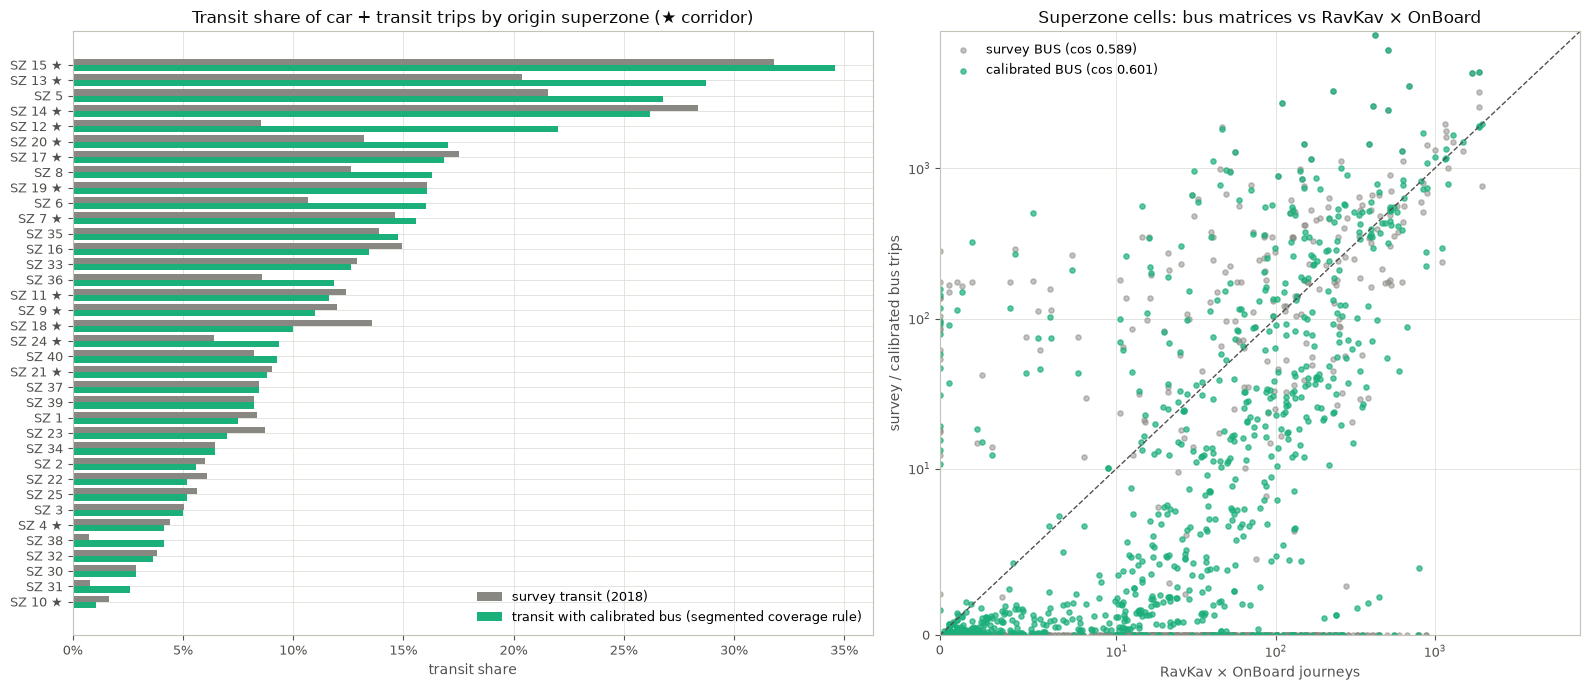

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='white', gridspec_kw={'width_ratios': [1.25, 1]})
t = sz_ms.sort_values('transit share (calibrated)')
y = np.arange(len(t)); ax = axes[0]
ax.barh(y + 0.2, t['transit share (survey)'], height=0.4, color=MUTED, label='survey transit (2018)')
ax.barh(y - 0.2, t['transit share (calibrated)'], height=0.4, color=AQUA, label='transit with calibrated bus (segmented coverage rule)')
ax.set_yticks(y); ax.set_yticklabels([f"SZ {int(z)}{' ★' if c else ''}" for z, c in zip(t['origin SZ'], t['corridor'])], fontsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
style_ax(ax, 'Transit share of car + transit trips by origin superzone (★ corridor)', 'transit share')
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax = axes[1]
sv, ca, rkv = to_sz(MAT[('BUS', 'avg')]).ravel(), T_sz.ravel(), rk_sz.ravel()
ax.scatter(rkv, sv, s=14, alpha=0.5, color=MUTED, label=f'survey BUS (cos {cosine(sv, rkv):.3f})')
ax.scatter(rkv, ca, s=14, alpha=0.7, color=AQUA, label=f'calibrated BUS (cos {cosine(ca, rkv):.3f})')
lim = max(rkv.max(), sv.max()) * 1.05; ax.plot([0, lim], [0, lim], color=INK2, linestyle='--', linewidth=1)
ax.set_xscale('symlog', linthresh=10); ax.set_yscale('symlog', linthresh=10); ax.set_xlim(0, lim); ax.set_ylim(0, lim)
style_ax(ax, 'Superzone cells: bus matrices vs RavKav × OnBoard', 'RavKav × OnBoard journeys', 'survey / calibrated bus trips')
ax.legend(frameon=False, fontsize=9, loc='upper left')
plt.tight_layout(); save_show(fig, 'two_mode_transit_share.png')

## Notes and caveats

- **Entirely survey-based, cellular-free.** The car matrix and the taxi-type / rail components are the trips file alone (2018 level); the only external inputs are the zone keys and the 2020 population / employment used to split 1250-zones into TAZs, and — for the bus part — RavKav and OnBoard. Below the 1250-zone, the survey's TAZ detail is a population / employment split, not observation.
- **Zone keys.** `Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv` is Git-LFS-only; when only its pointer is present the notebook reads `Input/taz_keys_from_shapefile.csv` (built from `Input/TAZ_North/TAZ_North.shp`: same 778 TAZs, `SUPERZONE` = `SZ_NEW` and `ARZI_1270` = `TAZ_1270` for every TAZ, with TAZ 3602 → zone 101000 as in the keys table; verified against the cellular-signature partition of the committed matrices). Locality names per superzone come from `Input/sz_localities.csv`. The dominant superzone of a 1250-zone (used only for the sampled counts $n_A$, $m_B$) is now the one with the largest 2020 population among its child TAZs; the earlier TAZ-count rule broke ties by file order, which moved a few counts by ± 5.
- **Frames.** RavKav journeys start at the boarding stop and include non-residents; the survey starts at the doorstep and covers residents. At superzone level the two mostly coincide, except at transfer hubs (flagged in the factor table by leg boardings ≫ journeys), where the ticketing origin is where people change buses. The calibrated volumes are therefore right for corridor *boardings* and too concentrated for door-to-door demand at the hubs — as already documented for the ticketing matrix in `TRANSIT_DEMAND_PLAN.md`.
- **The segmented rule is asymmetric, and that shows in the total.** It adopts ticketing volumes wherever ticketing records at least half of the survey's trips (often more than the survey, at hubs up to 3 ×) and keeps survey volumes wherever it records less than half. The bus base therefore lands at 126,117 trips — above both the survey (116,083) and the ticketing extract (92,713) — and moves from 117,500 to 131,700 as the threshold goes from 0.3 to 0.7 (`bus_calibration_threshold_sensitivity.csv`). The local segment is where the guard bites (survey 62,090, ticketing 23,277: 28 guarded origin × segment cells, 17 of them local — 17 of the 36 superzones, including Haifa 14 and 16 at ratios 0.44–0.48 and Tiberias at 0.05); the inter-superzone segments end close to ticketing (65,917 vs 69,436). A ratio below 0.5 cannot say by itself whether ticketing misses trips (operators outside the extract, cash fares, un-geocoded stops) or the survey expansion overstates local bus travel — the review (§8) is explicit on this — so the threshold is a stated assumption and the four variants are published, not one estimate. The provider question (which operators the extract covers, whether cash / unvalidated boardings are in it) is still the way to settle it.
- **What moves and what does not.** Calibration changes the bus layer's volumes and shrinks its thin superzone rows toward the OnBoard pattern with a weight validated on independent household halves; it never touches car, taxi-type or rail, and the column (destination) totals are an outcome, reported against the OnBoard alightings rather than imposed. Against the RavKav × OnBoard matrix the segmented result scores slightly *below* the binary variant on cosine (0.60 vs 0.66 at superzone level) and above it on GEH < 5 (37 % vs 31 %), as expected from keeping more survey volume in local cells.
- **Vintage.** RavKav-volume segments are at May 2022; guarded segments, car, taxi-type and rail at 2018. `THS_2017_three_mode_2022.ipynb` levels them.